# 🤖 Notebook 3 — Training, Evaluasi & Hyperparameter Tuning
Model: Random Forest + Gradient Boosting (Ensemble Learning)  
Target: `failure_flag` — Klasifikasi kegagalan lokasi pertanian.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score, f1_score)

# Load data hasil preprocessing
data = pd.read_csv('../dataset/data_cleaned.csv')
selected_features = joblib.load('../output/selected_features.pkl')

X = data[selected_features]
y = data['failure_flag']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi target:")
print(y.value_counts())


Shape X: (682695, 18)
Shape y: (682695,)

Distribusi target:
failure_flag
0    455130
1    227565
Name: count, dtype: int64


## 1. Split Data Train & Test

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")


Train: (546156, 18), Test: (136539, 18)
Train target distribution:
failure_flag
0    364104
1    182052
Name: count, dtype: int64

Test target distribution:
failure_flag
0    91026
1    45513
Name: count, dtype: int64


## 2. Baseline Model — Perbandingan Beberapa Model

In [3]:
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== Cross-Validation (5-Fold) Baseline ===")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = scores
    print(f"{name:25s} | F1 Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")


=== Cross-Validation (5-Fold) Baseline ===
Logistic Regression       | F1 Mean: 0.9427 | Std: 0.0007
Decision Tree             | F1 Mean: 0.9997 | Std: 0.0000
Random Forest             | F1 Mean: 1.0000 | Std: 0.0000
Gradient Boosting         | F1 Mean: 0.9999 | Std: 0.0000


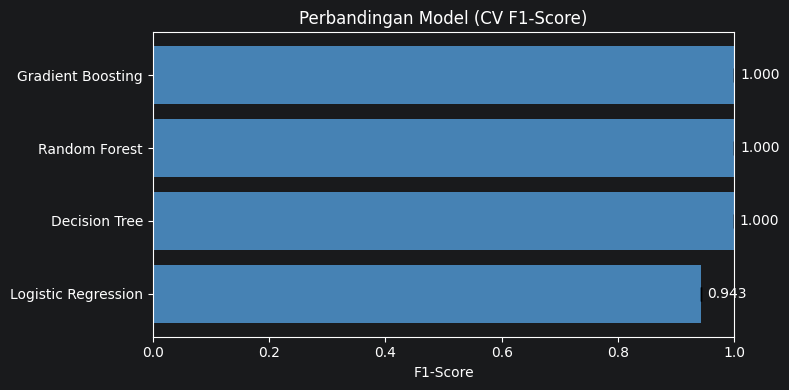

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [r.mean() for r in results.values()]
stds = [r.std() for r in results.values()]
bars = ax.barh(names, means, xerr=stds, capsize=5, color='steelblue')
ax.set_title('Perbandingan Model (CV F1-Score)')
ax.set_xlabel('F1-Score')
ax.set_xlim(0, 1)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + 0.01, i, f'{m:.3f}', va='center')
plt.tight_layout()
plt.show()


## 3. Hyperparameter Tuning — Random Forest

In [5]:
# RandomizedSearchCV untuk Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_dist_rf, n_iter=20, cv=cv,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print("\nBest params RF:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params RF: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 12}
Best CV F1: 1.0000


## 4. Hyperparameter Tuning — Gradient Boosting

In [ ]:
param_dist_gb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0],
}

gb_base = GradientBoostingClassifier(random_state=42)
gb_search = RandomizedSearchCV(
    gb_base, param_dist_gb, n_iter=15, cv=cv,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print("\nBest params GB:", gb_search.best_params_)
print(f"Best CV F1: {gb_search.best_score_:.4f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits


## 5. Ensemble — Voting Classifier (RF + GB + LR)

In [ ]:
best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_
lr = LogisticRegression(max_iter=500, random_state=42)

ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('lr', lr),
    ],
    voting='soft',
    n_jobs=-1
)
ensemble.fit(X_train, y_train)
print("Ensemble model berhasil dilatih.")

# Evaluasi ensemble dengan CV
scores = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f"Ensemble CV F1: {scores.mean():.4f} ± {scores.std():.4f}")


## 6. Evaluasi Final pada Data Test

In [ ]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))
    return y_pred, y_prob, acc, f1, auc

print("Evaluasi Model pada Data Test:")
preds = {}
for name, model in [('Random Forest', best_rf), ('Gradient Boosting', best_gb), ('Ensemble', ensemble)]:
    y_pred, y_prob, acc, f1, auc = evaluate_model(model, name, X_test, y_test)
    preds[name] = (y_pred, y_prob, acc, f1, auc)


## 7. Confusion Matrix

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (y_pred, y_prob, acc, f1, auc)) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    ax.set_title(f'{name}\nF1={f1:.3f} | AUC={auc:.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrix Perbandingan Model', fontsize=13)
plt.tight_layout()
plt.show()


## 8. ROC Curve

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'green']
for (name, (y_pred, y_prob, acc, f1, auc)), color in zip(preds.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Feature Importance (Random Forest)

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("=== Feature Importance (Top 15) ===")
print(importances.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest (Top 15)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## 10. Pilih Model Terbaik & Simpan

In [ ]:
# Pilih model dengan F1-Score tertinggi
best_name = max(preds, key=lambda k: preds[k][3])
print(f"\nModel terbaik berdasarkan F1-Score: {best_name}")
print(f"  F1: {preds[best_name][3]:.4f}")
print(f"  AUC: {preds[best_name][4]:.4f}")

model_map = {
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'Ensemble': ensemble,
}
final_model = model_map[best_name]

# Simpan model
joblib.dump(final_model, '../model/model.pkl')
print(f"\n✅ Model disimpan ke: ../model/model.pkl")


## 11. Verifikasi Model Tersimpan

In [ ]:
loaded_model = joblib.load('../model/model.pkl')
y_pred_check = loaded_model.predict(X_test[:5])
print("=== Prediksi dari model yang dimuat ===")
print("Prediksi:", y_pred_check)
print("Aktual  :", y_test.values[:5])
print("\n✅ Model berhasil dimuat dan berfungsi dengan baik.")


## ✅ Ringkasan Training
- Model yang dibandingkan: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting
- Hyperparameter tuning dengan `RandomizedSearchCV` + `StratifiedKFold` (5-fold CV)
- Ensemble `VotingClassifier` (soft voting) menggabungkan RF + GB + LR
- Model terbaik dipilih berdasarkan F1-Score pada test set
- Model final disimpan sebagai `output/model.pkl`
